In [1]:
# -*- coding: utf-8 -*-

import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import math, time
from sklearn.metrics import mean_squared_error
import plotly.express as px
import plotly.graph_objects as go
import chardet
import time
import joblib

import matplotlib.pyplot as plt
plt.rcParams["font.family"] = ["SimHei", "WenQuanYi Micro Hei", "Heiti TC"]

import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"

In [2]:
file_path = 'OutputData/merged_data.csv'
# 检测文件编码
with open(file_path, 'rb') as f:
    result = chardet.detect(f.read())

# 使用检测到的编码
encoding = result['encoding']
df = pd.read_csv(file_path, encoding=encoding)
df

,日期,经度,纬度,高程,日降雨量,涌水量
0,2023-01-01,400093.254,3044617.466,340,1.747,201.500
1,2023-01-02,400093.254,3044617.466,340,3.160,201.125
2,2023-01-03,400093.254,3044617.466,340,0.857,200.750
3,2023-01-04,400093.254,3044617.466,340,1.712,200.375
4,2023-01-05,400093.254,3044617.466,340,1.942,200.000
...,...,...,...,...,...,...
4149,2024-05-07,401223.552,3044155.756,670,10.717,17.600
4150,2024-05-08,401223.552,3044155.756,670,5.388,17.200
4151,2024-05-09,401223.552,3044155.756,670,3.532,16.800
4152,2024-05-10,401223.552,3044155.756,670,0.221,16.400


# 划分数据集函数

In [4]:
# target为要输入的数据,lookback为序列长度
# def split_data(target, lookback):
#     data_raw = target.to_numpy() 
#     data = []
    
#     # you can free play（seq_length）
#     for index in range(len(data_raw) - lookback + 1 ): 
#         data.append(data_raw[index: index + lookback])
    
#     data = np.array(data);

#     #手动设置测试集为30天
#     test_set_size = 30
#     train_set_size = data.shape[0] - (test_set_size)
    
#     x_train = data[:train_set_size,:-1,:]
#     y_train = data[:train_set_size,-1,1:]
    
#     x_test = data[train_set_size:,:-1,:]
#     y_test = data[train_set_size:,-1,1:]
    
#     return [x_train, y_train, x_test, y_test]

In [5]:
# target为要输入的数据,lookback为序列长度
def split_data(target, lookback, test_ratio=0.1, val_ratio=0.1):
    data_raw = target.to_numpy() 
    data = []
    
    # 构建序列数据
    for index in range(len(data_raw) - lookback + 1): 
        data.append(data_raw[index: index + lookback])
    
    data = np.array(data)
    
    # 计算数据集大小
    total_size = data.shape[0]
    test_set_size = int(total_size * test_ratio)
    val_set_size = int(total_size * val_ratio)
    train_set_size = total_size - test_set_size - val_set_size
    
    # 分割数据集
    # 注意:不可以写为y_train = data[:train_set_size, -1, 1:],这样写维度会报错
    x_train = data[:train_set_size, :-1, :]
    y_train = data[:train_set_size, -1, 1:]
    
    x_val = data[train_set_size:train_set_size+val_set_size, :-1, :]
    y_val = data[train_set_size:train_set_size+val_set_size, -1, 1:]
    
    x_test = data[train_set_size+val_set_size:, :-1, :]
    y_test = data[train_set_size+val_set_size:, -1, 1:]
    
    return [x_train, y_train, x_val, y_val, x_test, y_test]

# 模型构建

In [7]:
class LSTM(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers, output_dim):
        super(LSTM, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        c0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).requires_grad_()
        out, (hn, cn) = self.lstm(x, (h0.detach(), c0.detach()))
        out = self.fc(out[:, -1, :]) 
        return out

In [8]:
# 简单的日志记录器，支持日志恢复功能
class Logger:
    def __init__(self, log_file_path):
        self.log_file = log_file_path

        # 创建日志目录（如果不存在）
        os.makedirs(os.path.dirname(log_file_path), exist_ok=True)

        # 清空日志文件内容或创建新文件
        try:
            with open(log_file_path, 'w', encoding='utf-8') as f:
                f.write(f"训练开始: {time.strftime('%Y-%m-%d %H:%M:%S')}\n")
        except Exception as e:
            print(f"日志写入失败: {e}")

    def log(self, message):
        """记录日志到文件并打印到控制台"""
        print(message)  # 保持原有打印

        # 写入主日志文件
        with open(self.log_file, 'a', encoding='utf-8') as f:
            f.write(f"{message}\n")

Group: (400093.254, 3044617.466, 340)
模型标准化格式保存路径：lstmscaler/(400093.254, 3044617.466, 340)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(400093.254, 3044617.466, 340)best_model.pth
Epoch 0 MSE: 0.3254317045211792
Epoch 0 val RMSE: 9.549012489591119
Best model saved at epoch 0 with Test RMSE: 9.549012489591119
Epoch 1 MSE: 0.3328663110733032
Epoch 1 val RMSE: 11.365528229413437
Epoch 2 MSE: 0.26980578899383545
Epoch 2 val RMSE: 17.01713595937241
Epoch 3 MSE: 0.11737742274999619
Epoch 3 val RMSE: 42.26554413116108
Epoch 4 MSE: 0.300042986869812
Epoch 4 val RMSE: 14.520556906536903
Epoch 5 MSE: 0.05112329497933388
Epoch 5 val RMSE: 6.36840029908491
Best model saved at epoch 5 with Test RMSE: 6.36840029908491
Epoch 6 MSE: 0.09310074895620346
Epoch 6 val RMSE: 12.386804980384179
Epoch 7 MSE: 0.12512730062007904
Epoch 7 val RMSE: 16.65364165933

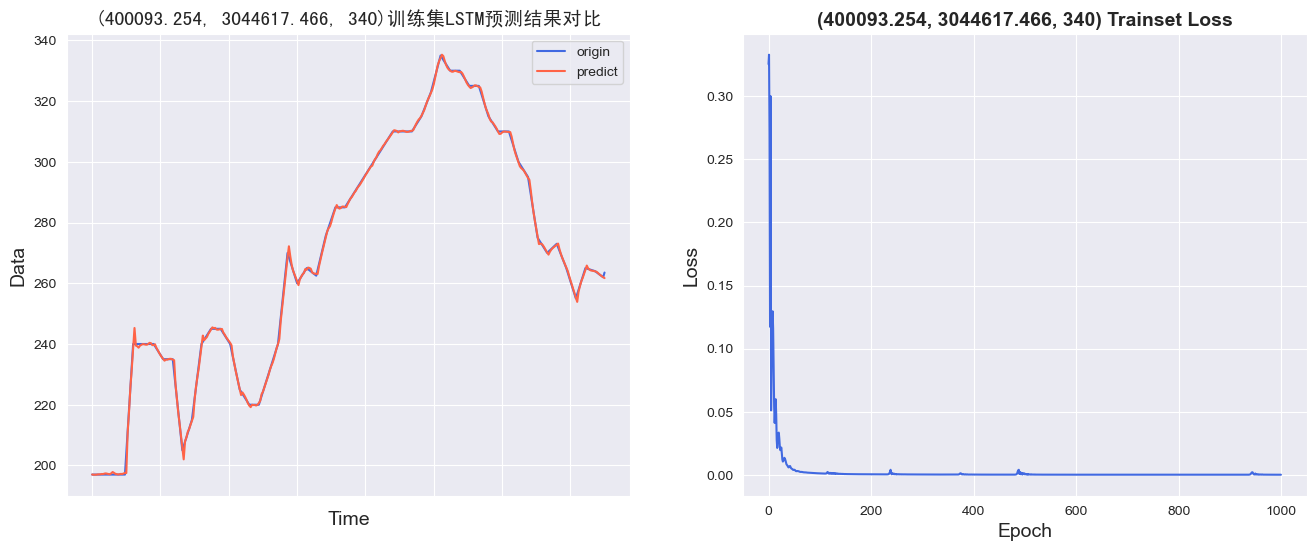

Train Score: 0.79 RMSE
Train Score: 0.61 RMSE
Test Score: 0.54 RMSE
./images/(400093.254, 3044617.466, 340)真实值vs预测值.png保存成功


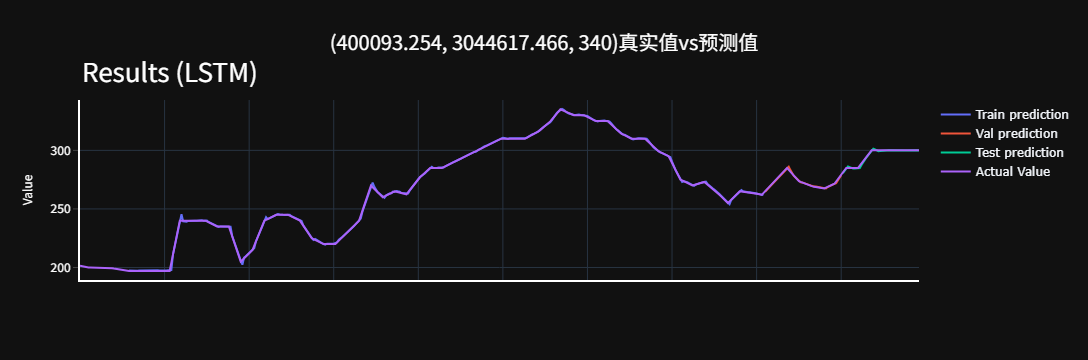

Group: (400119.158, 3044703.654, 670)
模型标准化格式保存路径：lstmscaler/(400119.158, 3044703.654, 670)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(400119.158, 3044703.654, 670)best_model.pth
Epoch 0 MSE: 0.5174456238746643
Epoch 0 val RMSE: 21.529680922961475
Best model saved at epoch 0 with Test RMSE: 21.529680922961475
Epoch 1 MSE: 0.2634424567222595
Epoch 1 val RMSE: 42.07922302921226
Epoch 2 MSE: 0.03200806304812431
Epoch 2 val RMSE: 105.25185568435361
Epoch 3 MSE: 1.2781058549880981
Epoch 3 val RMSE: 58.7728658128849
Epoch 4 MSE: 0.10126610845327377
Epoch 4 val RMSE: 35.11593869442514
Epoch 5 MSE: 0.0783746987581253
Epoch 5 val RMSE: 29.540610082443603
Epoch 6 MSE: 0.14201898872852325
Epoch 6 val RMSE: 28.26157162409873
Epoch 7 MSE: 0.15885184705257416
Epoch 7 val RMSE: 28.52855229236909
Epoch 8 MSE: 0.15374299883842468
Epoch 8 val RMSE: 29.69

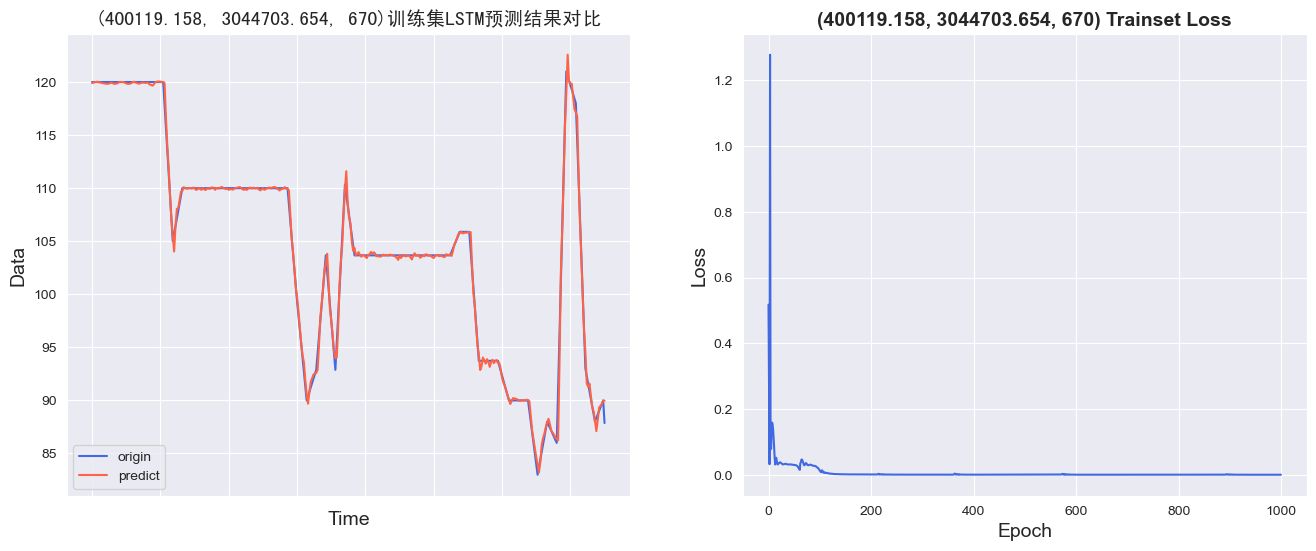

Train Score: 0.53 RMSE
Train Score: 14.46 RMSE
Test Score: 45.87 RMSE
./images/(400119.158, 3044703.654, 670)真实值vs预测值.png保存成功


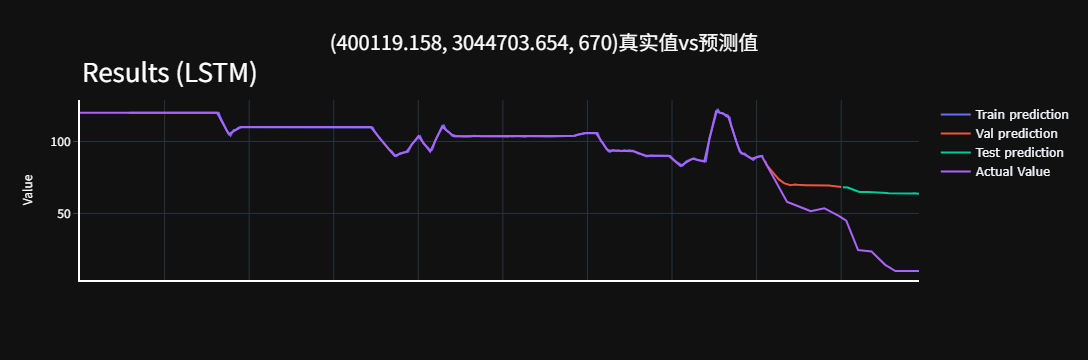

Group: (400277.273, 3044902.064, 430)
模型标准化格式保存路径：lstmscaler/(400277.273, 3044902.064, 430)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(400277.273, 3044902.064, 430)best_model.pth
Epoch 0 MSE: 0.35722070932388306
Epoch 0 val RMSE: 8.754094065226397
Best model saved at epoch 0 with Test RMSE: 8.754094065226397
Epoch 1 MSE: 0.25244662165641785
Epoch 1 val RMSE: 11.527855350177212
Epoch 2 MSE: 0.3413262963294983
Epoch 2 val RMSE: 9.145029737988358
Epoch 3 MSE: 0.2315371036529541
Epoch 3 val RMSE: 8.475940087315951
Best model saved at epoch 3 with Test RMSE: 8.475940087315951
Epoch 4 MSE: 0.25273966789245605
Epoch 4 val RMSE: 8.218898989411205
Best model saved at epoch 4 with Test RMSE: 8.218898989411205
Epoch 5 MSE: 0.26092374324798584
Epoch 5 val RMSE: 8.079765345121514
Best model saved at epoch 5 with Test RMSE: 8.079765345121514
Epoch 6 

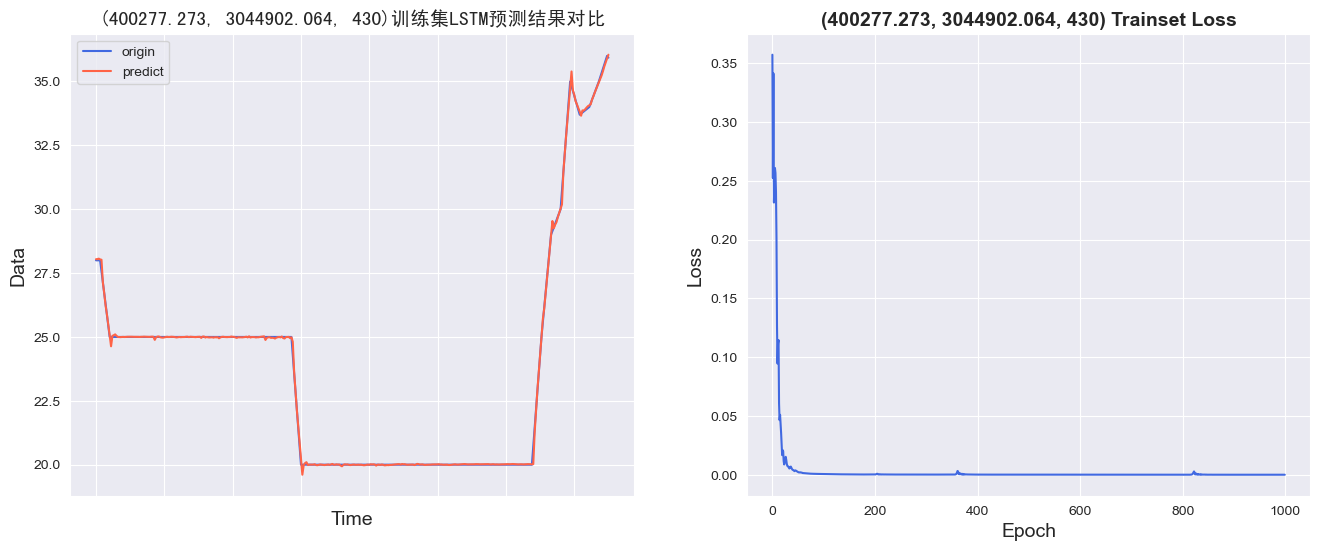

Train Score: 0.13 RMSE
Train Score: 0.44 RMSE
Test Score: 0.34 RMSE
./images/(400277.273, 3044902.064, 430)真实值vs预测值.png保存成功


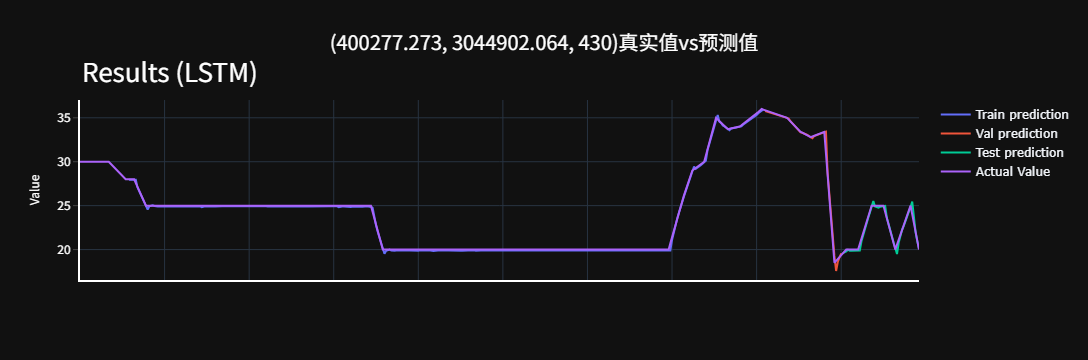

Group: (400530.275, 3043926.857, 670)
模型标准化格式保存路径：lstmscaler/(400530.275, 3043926.857, 670)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(400530.275, 3043926.857, 670)best_model.pth
Epoch 0 MSE: 0.15131427347660065
Epoch 0 val RMSE: 3.0096165386806177
Best model saved at epoch 0 with Test RMSE: 3.0096165386806177
Epoch 1 MSE: 0.16809330880641937
Epoch 1 val RMSE: 6.019392146855607
Epoch 2 MSE: 0.13865779340267181
Epoch 2 val RMSE: 9.466890561675374
Epoch 3 MSE: 0.13223335146903992
Epoch 3 val RMSE: 14.225982771514582
Epoch 4 MSE: 0.09619023650884628
Epoch 4 val RMSE: 23.386718423772336
Epoch 5 MSE: 0.045079343020915985
Epoch 5 val RMSE: 13.713218181932112
Epoch 6 MSE: 0.053161974996328354
Epoch 6 val RMSE: 15.884163201912779
Epoch 7 MSE: 0.051912691444158554
Epoch 7 val RMSE: 17.391726120519834
Epoch 8 MSE: 0.034413453191518784
Epoch 8 val

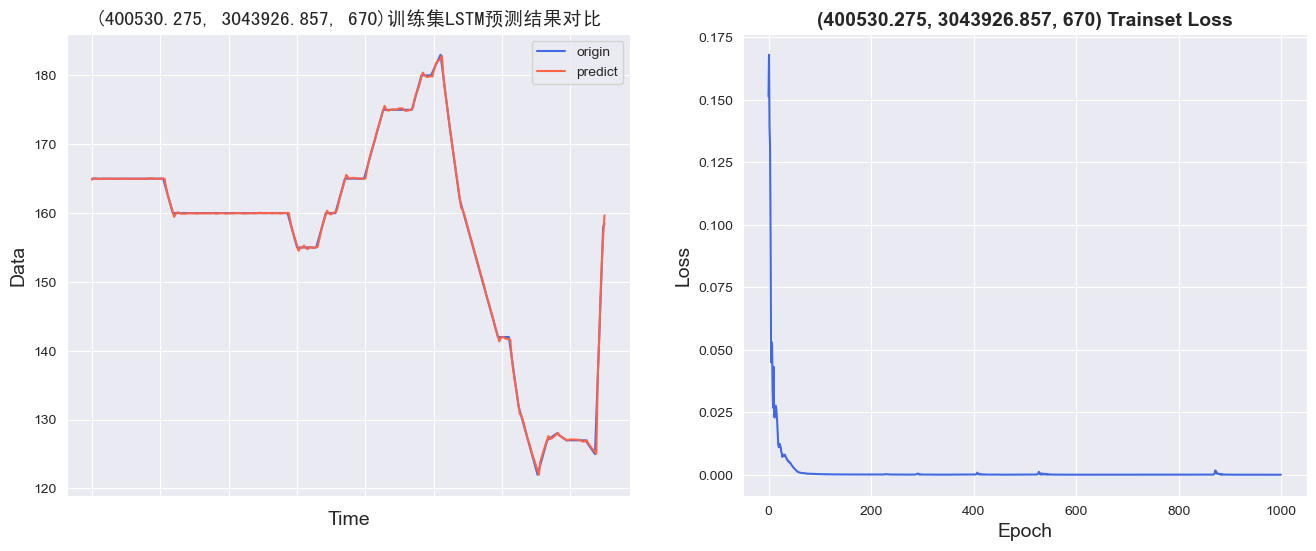

Train Score: 0.51 RMSE
Train Score: 0.51 RMSE
Test Score: 1.05 RMSE
./images/(400530.275, 3043926.857, 670)真实值vs预测值.png保存成功


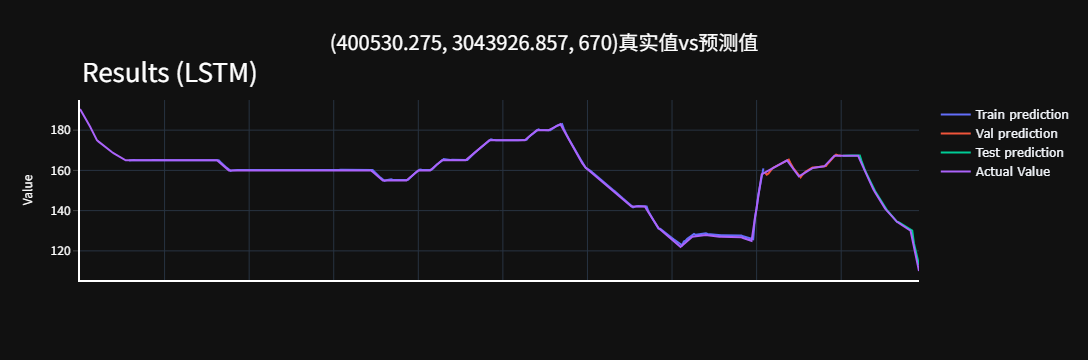

Group: (401142.234, 3043998.544, 490)
模型标准化格式保存路径：lstmscaler/(401142.234, 3043998.544, 490)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(401142.234, 3043998.544, 490)best_model.pth
Epoch 0 MSE: 0.23732542991638184
Epoch 0 val RMSE: 23.411218337433205
Best model saved at epoch 0 with Test RMSE: 23.411218337433205
Epoch 1 MSE: 0.04820096865296364
Epoch 1 val RMSE: 54.62846367022186
Epoch 2 MSE: 1.5612038373947144
Epoch 2 val RMSE: 26.57292189847884
Epoch 3 MSE: 0.0352032370865345
Epoch 3 val RMSE: 20.476279328450243
Best model saved at epoch 3 with Test RMSE: 20.476279328450243
Epoch 4 MSE: 0.09422417730093002
Epoch 4 val RMSE: 18.896998640450487
Best model saved at epoch 4 with Test RMSE: 18.896998640450487
Epoch 5 MSE: 0.13154393434524536
Epoch 5 val RMSE: 18.540796609531522
Best model saved at epoch 5 with Test RMSE: 18.540796609531522
E

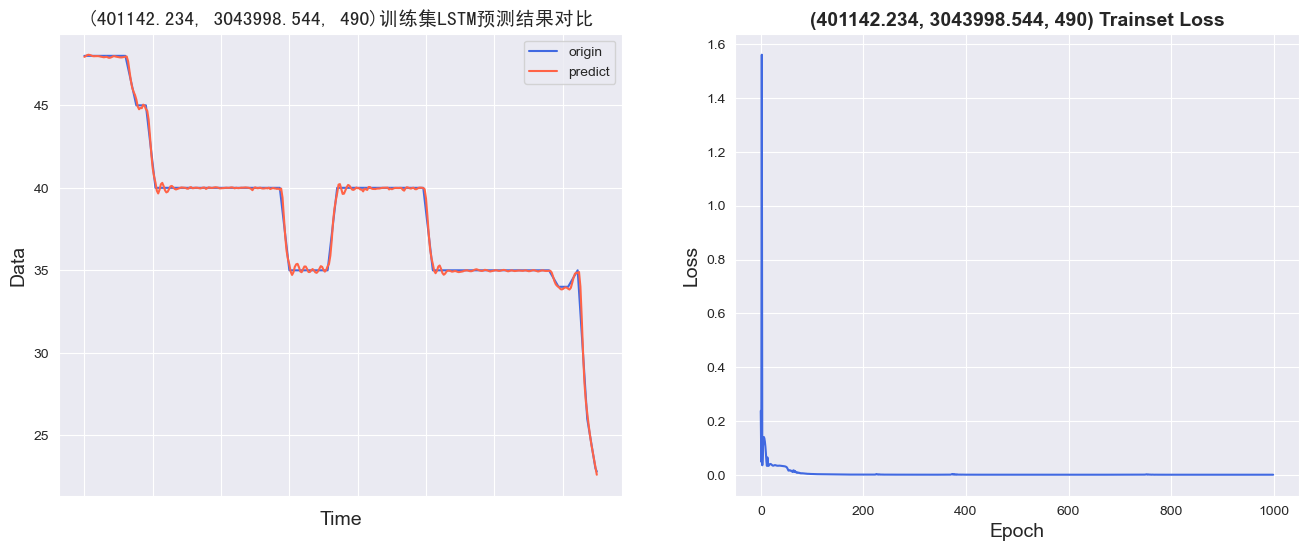

Train Score: 0.34 RMSE
Train Score: 5.61 RMSE
Test Score: 11.01 RMSE
./images/(401142.234, 3043998.544, 490)真实值vs预测值.png保存成功


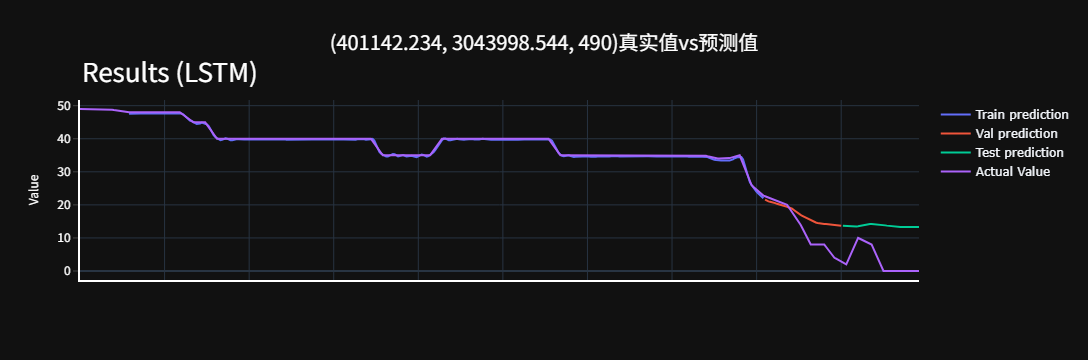

Group: (401142.234, 3043998.544, 760)
模型标准化格式保存路径：lstmscaler/(401142.234, 3043998.544, 760)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(401142.234, 3043998.544, 760)best_model.pth
Epoch 0 MSE: 0.35432133078575134
Epoch 0 val RMSE: 1.096569242546375
Best model saved at epoch 0 with Test RMSE: 1.096569242546375
Epoch 1 MSE: 0.12961164116859436
Epoch 1 val RMSE: 5.172724812463315
Epoch 2 MSE: 0.3910102844238281
Epoch 2 val RMSE: 1.8820893097786062
Epoch 3 MSE: 0.07470689713954926
Epoch 3 val RMSE: 1.1389855922695349
Epoch 4 MSE: 0.1270383596420288
Epoch 4 val RMSE: 0.946493593203327
Best model saved at epoch 4 with Test RMSE: 0.946493593203327
Epoch 5 MSE: 0.14759470522403717
Epoch 5 val RMSE: 0.950901721603451
Epoch 6 MSE: 0.14699594676494598
Epoch 6 val RMSE: 1.0615998550324388
Epoch 7 MSE: 0.1348000317811966
Epoch 7 val RMSE: 1.261851111

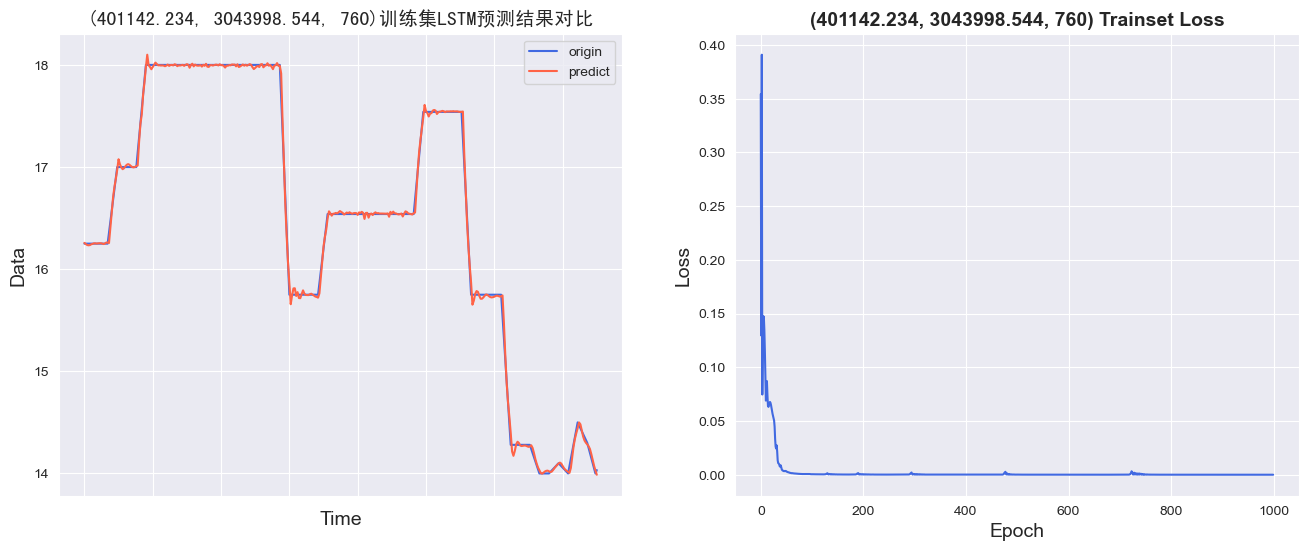

Train Score: 0.04 RMSE
Train Score: 0.04 RMSE
Test Score: 3.14 RMSE
./images/(401142.234, 3043998.544, 760)真实值vs预测值.png保存成功


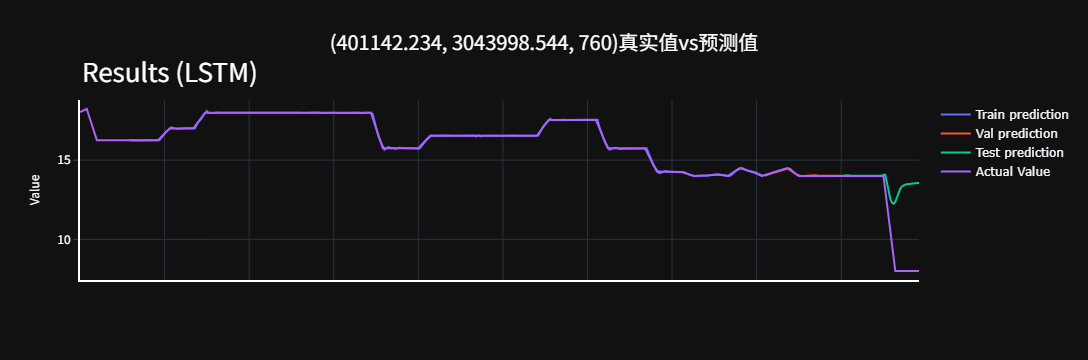

Group: (401223.552, 3044155.756, 490)
模型标准化格式保存路径：lstmscaler/(401223.552, 3044155.756, 490)best_scaler.pkl
x_train.shape =  (121, 29, 2)
y_train.shape =  (121, 1)
x_val.shape =  (14, 29, 2)
y_val.shape =  (14, 1)
x_test.shape =  (14, 29, 2)
y_test.shape =  (14, 1)
最优模型参数保存路径：lstmmodel/(401223.552, 3044155.756, 490)best_model.pth
Epoch 0 MSE: 0.11131089925765991
Epoch 0 val RMSE: 40.00908405150791
Best model saved at epoch 0 with Test RMSE: 40.00908405150791
Epoch 1 MSE: 0.06576433777809143
Epoch 1 val RMSE: 47.968233405198745
Epoch 2 MSE: 0.0987602099776268
Epoch 2 val RMSE: 38.66742714320414
Best model saved at epoch 2 with Test RMSE: 38.66742714320414
Epoch 3 MSE: 0.06568659096956253
Epoch 3 val RMSE: 36.16343212752611
Best model saved at epoch 3 with Test RMSE: 36.16343212752611
Epoch 4 MSE: 0.07387376576662064
Epoch 4 val RMSE: 36.06663449815407
Best model saved at epoch 4 with Test RMSE: 36.06663449815407
Epoch 5 MSE: 0.07430607825517654
Epoch 5 val RMSE: 36.86579764677298
Epoch 6

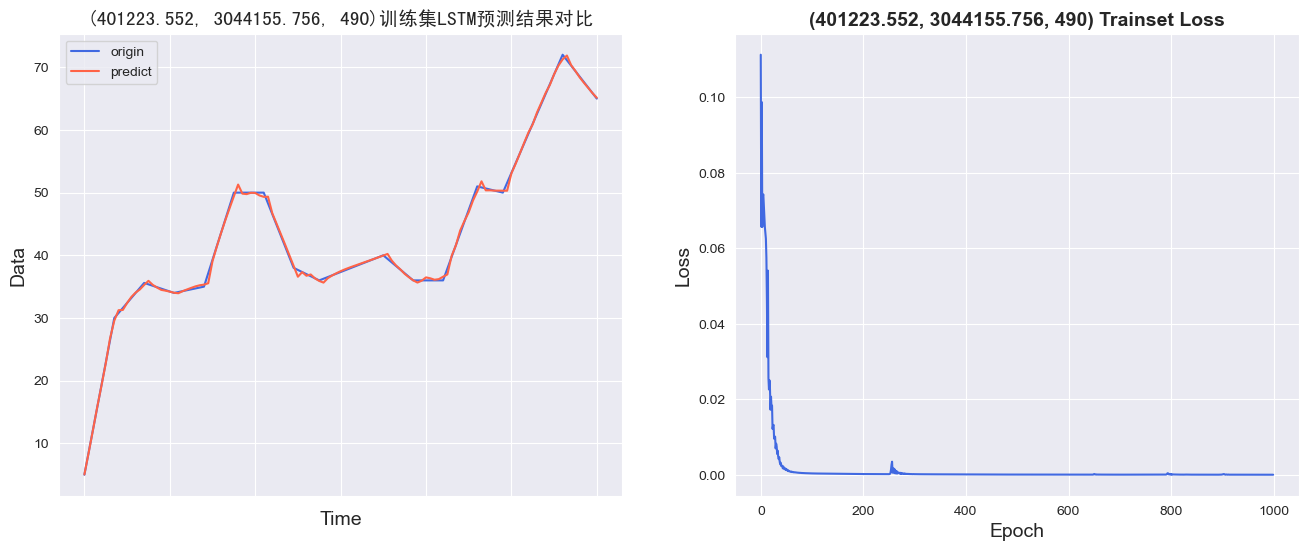

Train Score: 2.07 RMSE
Train Score: 5.17 RMSE
Test Score: 12.67 RMSE
./images/(401223.552, 3044155.756, 490)真实值vs预测值.png保存成功


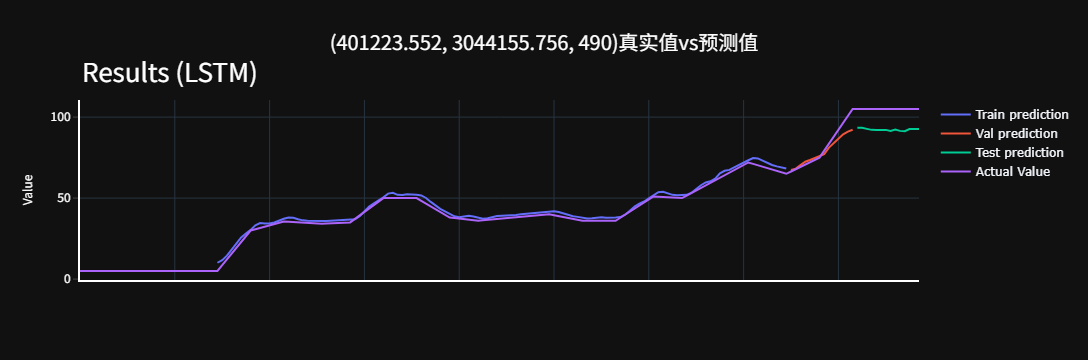

Group: (401223.552, 3044155.756, 610)
模型标准化格式保存路径：lstmscaler/(401223.552, 3044155.756, 610)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(401223.552, 3044155.756, 610)best_model.pth
Epoch 0 MSE: 0.23237204551696777
Epoch 0 val RMSE: 7.696254800333741
Best model saved at epoch 0 with Test RMSE: 7.696254800333741
Epoch 1 MSE: 0.19798095524311066
Epoch 1 val RMSE: 7.480621989700001
Best model saved at epoch 1 with Test RMSE: 7.480621989700001
Epoch 2 MSE: 0.18409870564937592
Epoch 2 val RMSE: 6.919093001356882
Best model saved at epoch 2 with Test RMSE: 6.919093001356882
Epoch 3 MSE: 0.15105842053890228
Epoch 3 val RMSE: 2.8992262432851663
Best model saved at epoch 3 with Test RMSE: 2.8992262432851663
Epoch 4 MSE: 0.091708242893219
Epoch 4 val RMSE: 12.729012962366475
Epoch 5 MSE: 0.10790213197469711
Epoch 5 val RMSE: 12.93646914295855
Epoch 

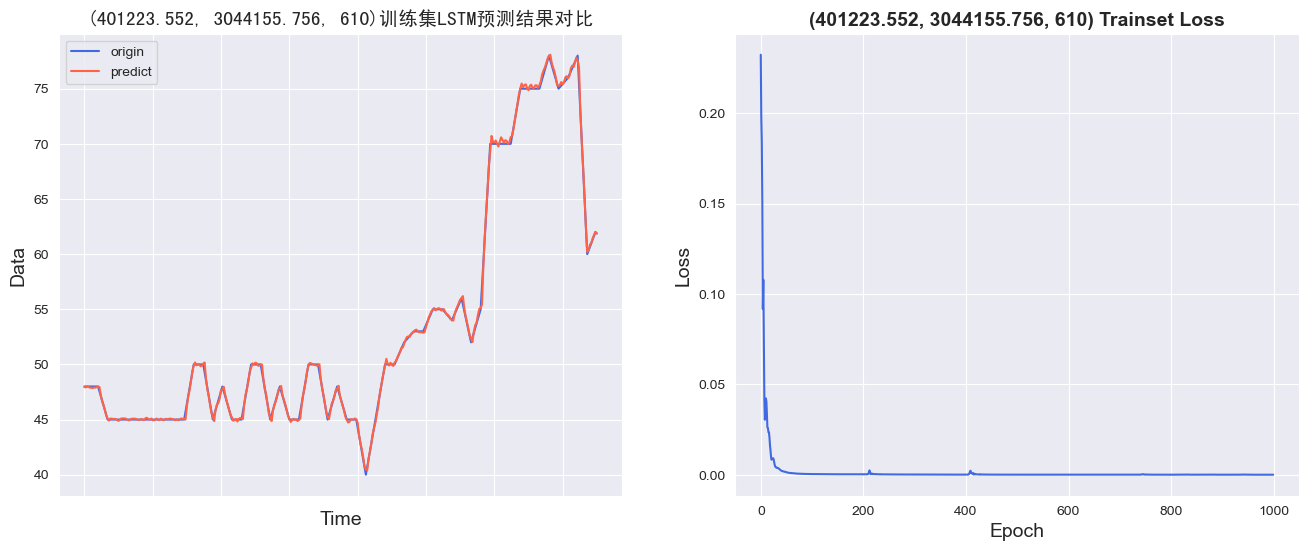

Train Score: 0.43 RMSE
Train Score: 0.29 RMSE
Test Score: 1.51 RMSE
./images/(401223.552, 3044155.756, 610)真实值vs预测值.png保存成功


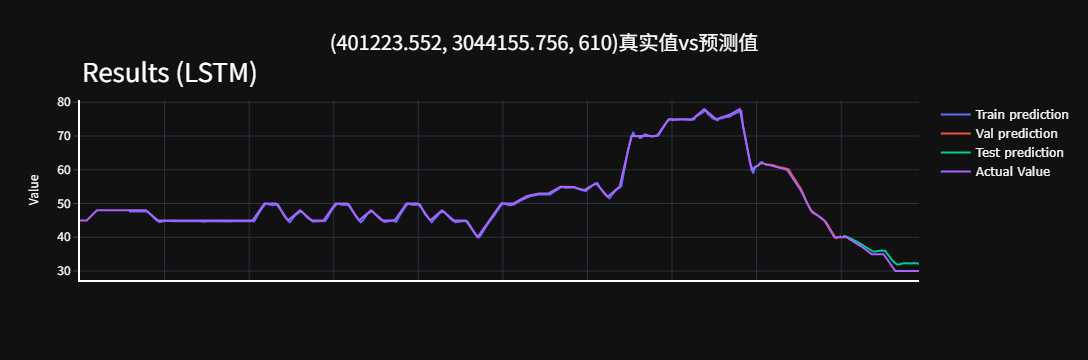

Group: (401223.552, 3044155.756, 670)
模型标准化格式保存路径：lstmscaler/(401223.552, 3044155.756, 670)best_scaler.pkl
x_train.shape =  (376, 29, 2)
y_train.shape =  (376, 1)
x_val.shape =  (46, 29, 2)
y_val.shape =  (46, 1)
x_test.shape =  (46, 29, 2)
y_test.shape =  (46, 1)
最优模型参数保存路径：lstmmodel/(401223.552, 3044155.756, 670)best_model.pth
Epoch 0 MSE: 0.2255275398492813
Epoch 0 val RMSE: 5.910565127028853
Best model saved at epoch 0 with Test RMSE: 5.910565127028853
Epoch 1 MSE: 0.2524465322494507
Epoch 1 val RMSE: 4.135531535182777
Best model saved at epoch 1 with Test RMSE: 4.135531535182777
Epoch 2 MSE: 0.2059268355369568
Epoch 2 val RMSE: 3.102351551915476
Best model saved at epoch 2 with Test RMSE: 3.102351551915476
Epoch 3 MSE: 0.19888995587825775
Epoch 3 val RMSE: 1.8926702738749137
Best model saved at epoch 3 with Test RMSE: 1.8926702738749137
Epoch 4 MSE: 0.17392583191394806
Epoch 4 val RMSE: 1.8837145152353758
Best model saved at epoch 4 with Test RMSE: 1.8837145152353758
Epoch 5 MSE: 

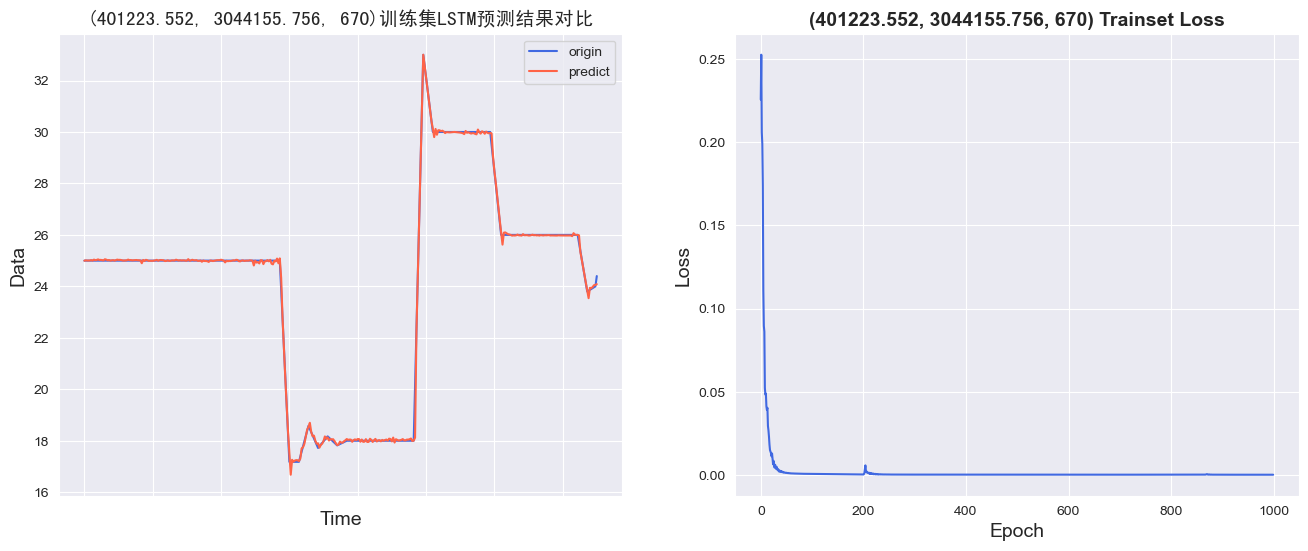

Train Score: 0.14 RMSE
Train Score: 0.27 RMSE
Test Score: 0.14 RMSE
./images/(401223.552, 3044155.756, 670)真实值vs预测值.png保存成功


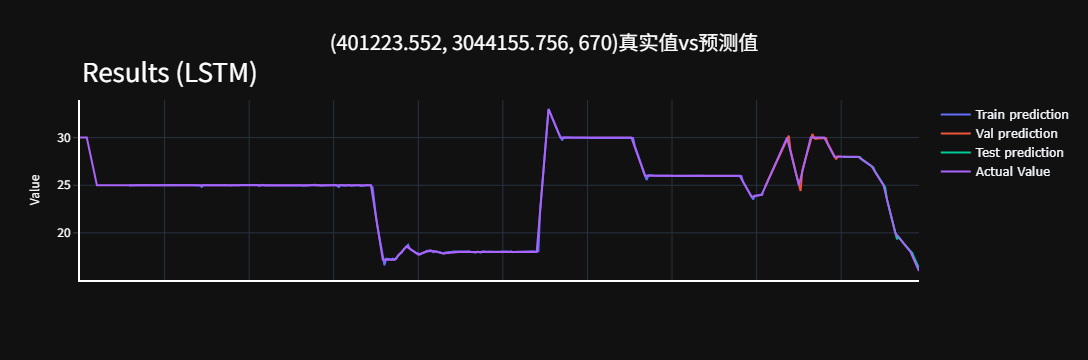

In [9]:
# 按'横坐标', '纵坐标', '高程'进行分组
grouped = df.groupby(['经度', '纬度', '高程'])

# 模型超参数
input_dim = 2
hidden_dim = 60
num_layers = 3
output_dim = 1
num_epochs = 1000
lookback = 30

# 该目录用于保存最优模型参数
os.makedirs('lstmmodel', exist_ok=True)

# 该目录用于保存最优模型训练数据标准化格式
os.makedirs('lstmscaler/', exist_ok=True)

# 创建日志目录
os.makedirs('logs', exist_ok=True)

for name, group in grouped:
    try:
        # 创建唯一的日志文件名
        log_file = f"logs/{name}training.log"
        logger = Logger(log_file)

        logger.log(f"Group: {name}")
        # 提取标签
        target = group[['日降雨量', '涌水量']].copy()

        # 归一化
        scaler = MinMaxScaler(feature_range=(-1, 1))
        target['日降雨量'] = scaler.fit_transform(target['日降雨量'].values.reshape(-1, 1))
        target['涌水量'] = scaler.fit_transform(target['涌水量'].values.reshape(-1, 1))

        best_scaler_path = 'lstmscaler/' + f'{name}' + 'best_scaler.pkl'
        logger.log('模型标准化格式保存路径：' + best_scaler_path)

        # 保存标准化参数
        joblib.dump(scaler, best_scaler_path)

        x_train, y_train, x_val, y_val, x_test, y_test = split_data(target, lookback)
        print('x_train.shape = ', x_train.shape)
        print('y_train.shape = ', y_train.shape)
        print('x_val.shape = ', x_val.shape)
        print('y_val.shape = ', y_val.shape)
        print('x_test.shape = ', x_test.shape)
        print('y_test.shape = ', y_test.shape)

        # 转换成张量,神经网络模型的数据要求为张量类型
        x_train = torch.from_numpy(x_train).type(torch.Tensor)
        x_test = torch.from_numpy(x_test).type(torch.Tensor)
        x_val = torch.from_numpy(x_val).type(torch.Tensor)
        y_train_lstm = torch.from_numpy(y_train).type(torch.Tensor)
        y_val_lstm = torch.from_numpy(y_val).type(torch.Tensor)
        y_test_lstm = torch.from_numpy(y_test).type(torch.Tensor)

        # 模型实例化准备开始训练
        model = LSTM(input_dim=input_dim, hidden_dim=hidden_dim, output_dim=output_dim, num_layers=num_layers)
        criterion = torch.nn.MSELoss()
        optimiser = torch.optim.Adam(model.parameters(), lr=0.01)

        hist = np.zeros(num_epochs)
        start_time = time.time()
        best_val_loss = float('inf')  # 用于保存验证集上的最佳损失
        best_model_path = 'lstmmodel/' + f'{name}' + 'best_model.pth'  # 最佳模型保存路径
        val_hist = np.zeros(num_epochs)  # 记录验证损失
        logger.log('最优模型参数保存路径：' + best_model_path)

        for t in range(num_epochs):
            # 训练模式
            model.train()

            y_train_pred = model(x_train)

            loss = criterion(y_train_pred, y_train_lstm)
            logger.log("Epoch " + str(t) + " MSE: " + str(loss.item()))
            hist[t] = loss.item()

            optimiser.zero_grad()
            loss.backward()
            optimiser.step()

            # 验证模式
            model.eval()
            with torch.no_grad():  # 禁用梯度计算
                y_val_pred = model(x_val)
                # 反归一化
                y_val_pred_1 = scaler.inverse_transform(y_val_pred.detach().numpy())
                y_val_1 = scaler.inverse_transform(y_val_lstm.detach().numpy())
                val_loss = math.sqrt(mean_squared_error(y_val_1[:, 0], y_val_pred_1[:, 0]))
                # print("Epoch ", t, "val RMSE: ", val_loss)
                logger.log("Epoch " + str(t) + " val RMSE: " + str(val_loss))
                val_hist[t] = val_loss

                # 如果验证损失更好，则保存模型
                if val_loss < best_val_loss:
                    best_val_loss = val_loss
                    torch.save(model.state_dict(), best_model_path)
                    # print(f"Best model saved at epoch {t} with Test RMSE: {best_val_loss}")
                    logger.log(f"Best model saved at epoch {t} with Test RMSE: {best_val_loss}")

        training_time = time.time() - start_time
        # print("Training time: {}".format(training_time))
        logger.log("Training time: {}".format(training_time))
        logger.log(f"{name} 训练完成\n")

        # 模型结果可视化
        predict = pd.DataFrame(scaler.inverse_transform(y_train_pred.detach().numpy()))
        original = pd.DataFrame(scaler.inverse_transform(y_train_lstm.detach().numpy()))
        sns.set_style("darkgrid")
        fig = plt.figure()
        fig.subplots_adjust(hspace=0.2, wspace=0.2)
        plt.subplot(1, 2, 1)
        ax = sns.lineplot(x=original.index, y=original[0], label="origin", color='royalblue')
        ax = sns.lineplot(x=predict.index, y=predict[0], label="predict", color='tomato')
        ax.set_title(f'{name}训练集LSTM预测结果对比', size=14, fontweight='bold', fontfamily=["SimHei"])
        ax.set_xlabel("Time", size=14)
        ax.set_ylabel("Data", size=14)
        ax.set_xticklabels('', size=10)

        plt.subplot(1, 2, 2)
        ax = sns.lineplot(data=hist, color='royalblue')
        ax.set_xlabel("Epoch", size=14)
        ax.set_ylabel("Loss", size=14)
        ax.set_title(f'{name} Trainset Loss', size=14, fontweight='bold')
        fig.set_figheight(6)
        fig.set_figwidth(16)
        # 保存训练集可视化结果到指定目录
        image_path = f'./images/{name}LSTM训练集可视化结果.png'
        plt.savefig(image_path, dpi=300, bbox_inches="tight")
        logger.log(f'./images/{name}LSTM训练集可视化结果.png保存成功')
        plt.show()

        # 加载最优模型参数
        model.load_state_dict(torch.load(best_model_path, weights_only=True))
        model.eval()  # 将模型设置为评估模式

        # 加载归一化格式
        scaler = joblib.load(best_scaler_path)

        # 在测试集上验证
        with torch.no_grad():  # 禁用梯度计算
            y_test_pred = model(x_test)
            y_train_pred = model(x_train)
            y_val_pred = model(x_val)

        # 归一化数据回到原来状态
        y_train_pred = scaler.inverse_transform(y_train_pred.detach().numpy())
        y_train = scaler.inverse_transform(y_train_lstm.detach().numpy())
        y_val_pred = scaler.inverse_transform(y_val_pred.detach().numpy())
        y_val = scaler.inverse_transform(y_val_lstm.detach().numpy())
        y_test_pred = scaler.inverse_transform(y_test_pred.detach().numpy())
        y_test = scaler.inverse_transform(y_test_lstm.detach().numpy())

        # 计算训练集、验证集和测试集的均方误差
        trainScore = math.sqrt(mean_squared_error(y_train[:, 0], y_train_pred[:, 0]))
        logger.log('Train Score: %.2f RMSE' % (trainScore))
        valScore = math.sqrt(mean_squared_error(y_val[:, 0], y_val_pred[:, 0]))
        logger.log('Train Score: %.2f RMSE' % (valScore))
        testScore = math.sqrt(mean_squared_error(y_test[:, 0], y_test_pred[:, 0]))
        logger.log('Test Score: %.2f RMSE' % (testScore))

        # 制作可视化数据集
        new_target = target[['涌水量']]

        # 转换数据
        trainPredictPlot = np.empty_like(new_target)
        trainPredictPlot[:, 0] = np.nan
        trainPredictPlot[lookback - 1:len(y_train_pred) + lookback - 1, :] = y_train_pred

        valPredictPlot = np.empty_like(new_target)
        valPredictPlot[:, 0] = np.nan
        valPredictPlot[len(y_train_pred) + lookback - 1:len(y_train_pred) + lookback - 1 + len(y_val_pred),
        :] = y_val_pred

        testPredictPlot = np.empty_like(new_target)
        testPredictPlot[:, :] = np.nan
        testPredictPlot[len(y_train_pred) + lookback - 1 + len(y_val_pred):, :] = y_test_pred

        original = scaler.inverse_transform(target['涌水量'].values.reshape(-1, 1))

        predictions = np.append(trainPredictPlot, valPredictPlot, axis=1)
        predictions = np.append(predictions, testPredictPlot, axis=1)
        predictions = np.append(predictions, original, axis=1)
        result = pd.DataFrame(predictions)

        # 将集合好的result画图可视化
        fig = go.Figure()
        fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[0],
                                            mode='lines',
                                            name='Train prediction')))
        fig.add_trace(go.Scatter(x=result.index, y=result[1],
                                 mode='lines',
                                 name='Val prediction'))
        fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[2],
                                            mode='lines',
                                            name='Test prediction')))
        fig.add_trace(go.Scatter(go.Scatter(x=result.index, y=result[3],
                                            mode='lines',
                                            name='Actual Value')))
        fig.update_layout(
            title={
                'text': f'{name}真实值vs预测值',  # 替换为您的标题文本
                'x': 0.5,  # 标题水平居中
                'xanchor': 'center',
                'y': 0.9,  # 标题在图表的顶部
                'yanchor': 'top',
                'font': {
                    'family': "Rockwell",
                    'size': 20,
                    'color': 'white'
                }
            },
            xaxis=dict(
                showline=True,
                showgrid=True,
                showticklabels=False,
                linecolor='white',
                linewidth=2
            ),
            yaxis=dict(
                title_text="Value",
                title_font=dict(
                    family='Rockwell',
                    size=12,
                    color='white',
                ),
                showline=True,
                showgrid=True,
                showticklabels=True,
                linecolor='white',
                linewidth=2,
                ticks='outside',
                tickfont=dict(
                    family='Rockwell',
                    size=12,
                    color='white',
                ),
            ),
            showlegend=True,
            template='plotly_dark'

        )

        annotations = []
        annotations.append(dict(xref='paper', yref='paper', x=0.0, y=1.05,
                                xanchor='left', yanchor='bottom',
                                text='Results (LSTM)',
                                font=dict(family='Rockwell',
                                          size=26,
                                          color='white'),
                                showarrow=False))
        fig.update_layout(annotations=annotations)
        # 保存可视化结果
        image_path = f'./images/{name}真实值vs预测值.png'
        fig.write_image(image_path, width=1200, height=600, scale=2,engine='orca')
        logger.log(f'./images/{name}真实值vs预测值.png保存成功')
        fig.show()
    except Exception as e:
        logger.log(f"训练过程中发生错误: {str(e)}")